# ResNet for comparison with the Encoder + MLP model

In [ ]:
data_dir = "/content/drive/MyDrive/SL_Project-20250508T132141Z-1-001/SL_Project/binary_one_type"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import os


Libraries were imported

In [ ]:
img_height, img_width = 224, 224  
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% train, 20% validation
    horizontal_flip=True,
    zoom_range=0.2,
    rotation_range=10
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 3028 images belonging to 2 classes.
Found 757 images belonging to 2 classes.


Dataset has been divided in Train and Validation Set 

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze the base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


We loaded the pre-trained weights and removed the original classification head, as our classification task differs from the one for which ResNet50 was originally designed.

In [ ]:
!cp -r "/content/drive/MyDrive/SL_Project-20250508T132141Z-1-001/SL_Project/binary_one_type" /content/
data_dir = "/content/binary_one_type"


In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model 
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 78s 712ms/step - accuracy: 0.6677 - loss: 0.5993 - val_accuracy: 0.7873 - val_loss: 0.5265
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 57s 596ms/step - accuracy: 0.7652 - loss: 0.5350 - val_accuracy: 0.7754 - val_loss: 0.5033
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 612ms/step - accuracy: 0.7783 - loss: 0.5108 - val_accuracy: 0.7979 - val_loss: 0.4792
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 607ms/step - accuracy: 0.7880 - loss: 0.4870 - val_accuracy: 0.7807 - val_loss: 0.4693
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 57s 596ms/step - accuracy: 0.7939 - loss: 0.4862 - val_accuracy: 0.7926 - val_loss: 0.4581
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 57s 606ms/step - accuracy: 0.7992 - loss: 0.4698 - val_accuracy: 0.8085 - val_loss: 0.4413
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 56s 594ms/step - accuracy: 0.8142 - loss: 0.4501 - val_accuracy: 0.8111 - val_loss: 0.4362
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 59s 626ms/step - accuracy: 0.8008 - loss: 0.4534 - val_accu

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# Unfreeze the last 50 layers of the base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Compile the model with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define callbacks for early stopping and learning rate reduction
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1)
]

# Fine-tune the model
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 99s 781ms/step - accuracy: 0.9507 - loss: 0.1292 - val_accuracy: 0.8996 - val_loss: 0.2713 - learning_rate: 1.0000e-05
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 119s 640ms/step - accuracy: 0.9574 - loss: 0.1155 - val_accuracy: 0.9498 - val_loss: 0.1513 - learning_rate: 1.0000e-05
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 612ms/step - accuracy: 0.9580 - loss: 0.1081 - val_accuracy: 0.9234 - val_loss: 0.1947 - learning_rate: 1.0000e-05
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9532 - loss: 0.1146
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 651ms/step - accuracy: 0.9533 - loss: 0.1146 - val_accuracy: 0.9419 - val_loss: 0.1732 - learning_rate: 1.0000e-05
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 615ms/step - accuracy: 0.9702 - loss: 0.0825 - val_accuracy: 0.9524 - val_loss: 0.1329 - learning_rate: 2.0000e-06
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 638ms/step - accurac

The fine-tuning process was performed over 10 epochs using a pre-trained ResNet50 model, with the last layers unfrozen. The initial learning rate was set to 1e-5 and later automatically reduced to 2e-6 via `ReduceLROnPlateau`.

- The model achieved strong and stable performance across all epochs, with validation accuracy improving consistently, reaching **96.3%** by the final epoch.
- Validation loss decreased significantly from **0.2713** to **0.1256**, suggesting better generalization.
- Notably, even after reducing the learning rate, the model maintained a high level of performance without overfitting, as seen from the close alignment between training and validation metrics.
- The learning rate adjustment around epoch 4 likely helped refine the model further by allowing smaller, more stable updates.

Overall, the results indicate a successful fine-tuning phase, with both accuracy and loss metrics confirming an effective adaptation of the pre-trained network to the new binary classification task.


Found 757 images belonging to 2 classes.
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 548ms/step


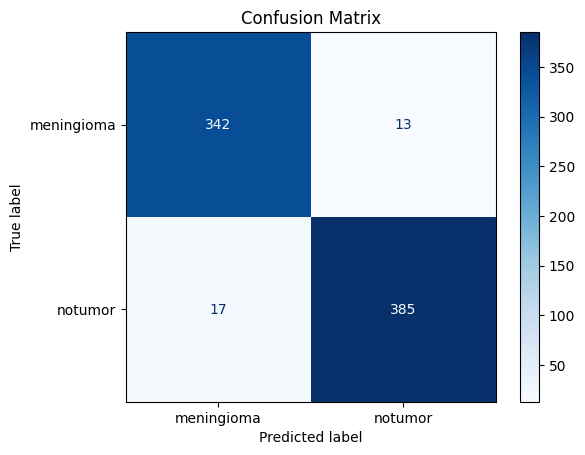


Classification Report:
              precision    recall  f1-score   support

  meningioma       0.95      0.96      0.96       355
     notumor       0.97      0.96      0.96       402

    accuracy                           0.96       757
   macro avg       0.96      0.96      0.96       757
weighted avg       0.96      0.96      0.96       757



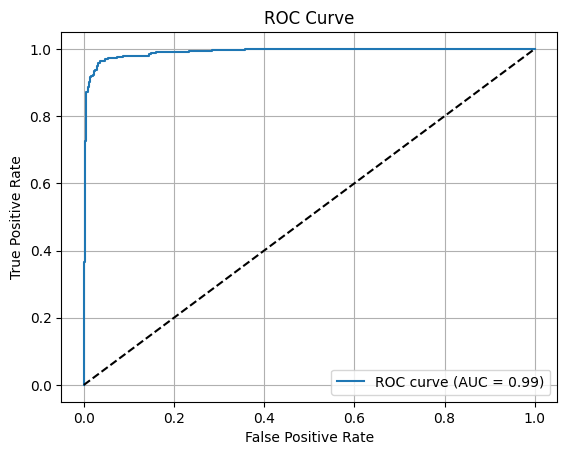

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False  # Important for evaluation metrics like confusion matrix and ROC curve
)

# Get predictions
val_gen.reset()
y_prob = model.predict(val_gen)
y_pred = (y_prob > 0.5).astype(int).ravel()
y_true = val_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_gen.class_indices.keys())
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys()))

# ROC Curve + AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


These images show the confusion matrix and the ROC curve, which demonstrate the effectiveness of the model.

In [ ]:
data_dir = "/content/drive/MyDrive/SL_Project-20250508T132141Z-1-001/SL_Project/binary_one_type"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import os


This script performs a structured split of the dataset into three subsets: **training (70%)**, **validation (15%)**, and **testing (15%)**. 

In [ ]:
import os
import shutil
import random

# Paths
original_dir = "/content/drive/MyDrive/SL_Project-20250508T132141Z-1-001/SL_Project/binary_one_type"
base_dir = "/content/binary_split"

# Splitting ratios
split_ratio = {'train': 0.7, 'val': 0.15, 'test': 0.15}
classes = ['meningioma', 'notumor']

# 1. Create directory structure for train/val/test splits
for split in split_ratio:
    for c in classes:
        os.makedirs(os.path.join(base_dir, split, c), exist_ok=True)

# 2. Loop through each class and split its images
for c in classes:
    # List all image files for the current class
    files = os.listdir(os.path.join(original_dir, c))
    random.shuffle(files)  # Shuffle to randomize selection
    n = len(files)

    # Compute split counts
    n_train = int(n * split_ratio['train'])
    n_val = int(n * split_ratio['val'])

    # Divide file names into subsets
    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    # Copy files to corresponding directories
    for fname in train_files:
        shutil.copy(os.path.join(original_dir, c, fname), os.path.join(base_dir, 'train', c, fname))
    for fname in val_files:
        shutil.copy(os.path.join(original_dir, c, fname), os.path.join(base_dir, 'val', c, fname))
    for fname in test_files:
        shutil.copy(os.path.join(original_dir, c, fname), os.path.join(base_dir, 'test', c, fname))


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32

# Image generator with rescaling (normalization between 0 and 1)
datagen = ImageDataGenerator(rescale=1./255)

# Training data generator (reads images from 'train' folder)
train_gen = datagen.flow_from_directory(
    base_dir + '/train',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'  # For binary classification
)

# Validation data generator (reads images from 'val' folder)
val_gen = datagen.flow_from_directory(
    base_dir + '/val',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Test data generator (reads images from 'test' folder)
test_gen = datagen.flow_from_directory(
    base_dir + '/test',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Important: don't shuffle to preserve label order for evaluation
)


Found 2649 images belonging to 2 classes.
Found 567 images belonging to 2 classes.
Found 569 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load the ResNet50 model without the top classification layer
base_model = ResNet50(
    weights='imagenet',         # Use pre-trained weights from ImageNet
    include_top=False,          # Exclude the final dense layers (classification head)
    input_shape=(img_height, img_width, 3)  # Input shape for the images
)
base_model.trainable = False   # Freeze the convolutional base to prevent weights update during initial training

# Build the full model by adding new classification layers on top of the frozen base
model = models.Sequential([
    base_model,                                # Pre-trained convolutional base
    layers.GlobalAveragePooling2D(),           # Global average pooling to reduce feature maps to a vector
    layers.Dense(128, activation='relu'),      # Fully connected layer with ReLU activation
    layers.Dropout(0.5),                        # Dropout for regularization to reduce overfitting
    layers.Dense(1, activation='sigmoid')      # Output layer for binary classification with sigmoid activation
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We loaded the pre-trained weights and removed the original classification head because our classification task differs from the one ResNet50 was originally designed for.

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model with Adam optimizer and binary crossentropy loss
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Standard learning rate for the head
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Initial training (train only the custom layers)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.5420 - loss: 0.7426 - val_accuracy: 0.7566 - val_loss: 0.5509
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.6719 - loss: 0.5808 - val_accuracy: 0.7848 - val_loss: 0.5020
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.7638 - loss: 0.5111 - val_accuracy: 0.8078 - val_loss: 0.4808
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.7880 - loss: 0.4849 - val_accuracy: 0.8025 - val_loss: 0.4610
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.7839 - loss: 0.4843 - val_accuracy: 0.7760 - val_loss: 0.4566
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.7900 - loss: 0.4595 - val_accuracy: 0.7919 - val_loss: 0.4393
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.8209 - loss: 0.4305 - val_accuracy: 0.8183 - val_loss: 0.4285
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.8139 - loss: 0.4284 - val_accuracy: 

Results without fine-tuning, already quite good.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Unfreeze the last 50 layers of the base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Compile the model with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks for early stopping and learning rate reduction
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.2, verbose=1)
]

# Fine-tune the model
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 396ms/step - accuracy: 0.7270 - loss: 1.5129 - val_accuracy: 0.5996 - val_loss: 0.5551 - learning_rate: 1.0000e-05
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.9106 - loss: 0.1943 - val_accuracy: 0.7143 - val_loss: 0.5029 - learning_rate: 1.0000e-05
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9683 - loss: 0.1048 - val_accuracy: 0.9383 - val_loss: 0.2135 - learning_rate: 1.0000e-05
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.9796 - loss: 0.0641 - val_accuracy: 0.9400 - val_loss: 0.1484 - learning_rate: 1.0000e-05
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 174ms/step - accuracy: 0.9735 - loss: 0.0683 - val_accuracy: 0.9841 - val_loss: 0.0732 - learning_rate: 1.0000e-05
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.9874 - loss: 0.0368 - val_accuracy: 0.9841 - val_loss: 0.0746 - learning_rate: 1.0000e-05
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accu

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step


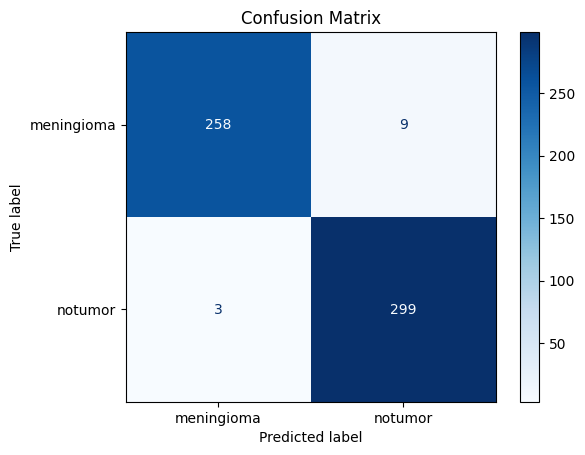


Classification Report:
              precision    recall  f1-score   support

  meningioma       0.99      0.97      0.98       267
     notumor       0.97      0.99      0.98       302

    accuracy                           0.98       569
   macro avg       0.98      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569



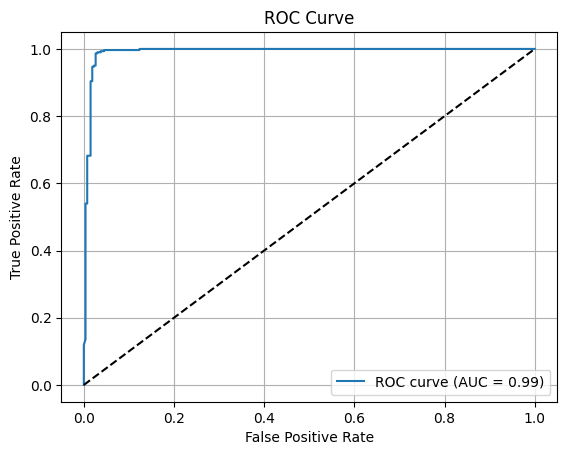

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

# Predict on the test set
test_gen.reset()
y_prob = model.predict(test_gen)
y_pred = (y_prob > 0.5).astype(int).ravel()
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))

# 📈 ROC curve + AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


The model demonstrates excellent performance with a final accuracy of 98% on the validation set. Precision, recall, and F1-scores are consistently high (~0.98) for both classes, indicating balanced and reliable classification. The AUC of 0.99 further confirms strong discriminative ability. The low number of false negatives (9 out of 267 positive cases) suggests the model is effective at correctly identifying true positive cases, which is critical in medical diagnosis scenarios.


In [ ]:
model.save('/content/resnet50_tumore_model.h5')
